<a href="https://colab.research.google.com/github/sdesai38/Projects/blob/main/UWV_SAC_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UWV Stream Crossing with SAC


Trains SAC with no obstacle, then ramps up obstacle linearly until full size. Actor-critic learns value function with no obstacle, uses best policy without obstacle. With addition of obstacle ramping up per step, actor-critic slowly improves policy with full size obstacle.

In [ ]:
import os, copy, random, math
from collections import deque
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED); random.seed(SEED)

device: cuda


## Environment with ramp up obs

In [ ]:
class UWVEnv:
    def __init__(self, dt=0.05, t_max=10.0, u_max=3.0, seed=None, obs_radius=0.4, goal_tol=0.15):
        self.dt = dt; self.t_max = t_max
        self.u_max = u_max
        self.max_steps = int(t_max / dt)
        self.start = np.array([0.0, -1.0])
        self.goal = np.array([0.0, 1.0])
        self.obs_center = np.array([0.5, 0.0])
        self.obs_radius = obs_radius
        self.x_bounds = (-2.0, 2.0)
        self.goal_tol = goal_tol
        self.v_avg = 1.0
        self.delta_range = 0.5
        self.alpha_energy = 0.05
        self.gamma_shape = 0.99
        self.r_goal = 200.0
        self.r_collide = -100.0
        self.r_oob = -50.0
        self.r_step = -0.05
        self.beta_landing = 20.0
        self.rng = np.random.default_rng(seed)
        self.reset()

    @property
    def state_dim(self): return 6
    @property
    def action_dim(self): return 2

    def reset(self):
        self.x, self.y = self.start
        self.vx = 0.0; self.vy = 0.0
        self.t_step = 0
        return self._obs()

    def _obs(self):
        # goal-relative + obstacle-relative observations, normalized
        return np.array([

            (self.goal[0] - self.x) / 2.0,
            (self.goal[1] - self.y) / 2.0,
            self.vx / 3.0,
            self.vy / 3.0,
            (self.obs_center[0] - self.x) / 2.0,
            (self.obs_center[1] - self.y) / 2.0,

        ], dtype=np.float32)

    def _dist_to_goal(self):
        return math.hypot(self.x - self.goal[0], self.y - self.goal[1])

    def _dist_to_obs(self):
        return math.hypot(self.x - self.obs_center[0], self.y - self.obs_center[1])

    def step(self, action):
        u1, u2 = np.clip(action, -self.u_max, self.u_max)

        phi_s = -self._dist_to_goal()

        vw = self.v_avg + self.rng.uniform(-self.delta_range, self.delta_range)
        self.x += (self.vx + vw) * self.dt
        self.y += self.vy * self.dt
        self.vx += u1 * self.dt
        self.vy += u2 * self.dt
        self.t_step += 1


        phi_s2 = -self._dist_to_goal()

        reward = self.r_step
        reward -= self.alpha_energy * (u1**2 + u2**2) * self.dt

        reward += self.gamma_shape * phi_s2 - phi_s

        done = False; info = {'event': 'running'}
        d_obs = self._dist_to_obs()
        d_goal = self._dist_to_goal()
        if d_obs < self.obs_radius:
            reward += self.r_collide; done = True; info['event'] = 'collision'
        elif self.x < self.x_bounds[0] or self.x > self.x_bounds[1] or self.y < -1.05:
            reward += self.r_oob; done = True; info['event'] = 'out_of_bounds'
        elif d_goal < self.goal_tol:
            reward += self.r_goal
            reward -= self.beta_landing * (self.vx**2 + self.vy**2)
            done = True; info['event'] = 'goal'
        elif self.t_step >= self.max_steps:
            done = True; info['event'] = 'timeout'

        return self._obs(), reward, done, info


env = UWVEnv(seed=0)
s = env.reset(); print('start obs:', s)

start obs: [0.   1.   0.   0.   0.25 0.5 ]


## SAC

In [ ]:
def mlp(sizes, act=nn.ReLU):
    layers = []
    for i in range(len(sizes) - 1):
        layers.append(nn.Linear(sizes[i], sizes[i+1]))
        if i < len(sizes) - 2: layers.append(act())
    return nn.Sequential(*layers)

class GaussianActor(nn.Module):
    LOG_STD_MIN, LOG_STD_MAX = -5, 2
    def __init__(self, sd, ad, u_max, hidden=256):
        super().__init__()
        self.trunk = mlp([sd, hidden, hidden])
        self.mu_head = nn.Linear(hidden, ad)
        self.logstd_head = nn.Linear(hidden, ad)
        self.u_max = u_max
    def forward(self, s):
        h = F.relu(self.trunk(s))
        mu = self.mu_head(h)
        log_std = torch.clamp(self.logstd_head(h), self.LOG_STD_MIN, self.LOG_STD_MAX)
        return mu, log_std
    def sample(self, s):
        mu, log_std = self(s)
        std = log_std.exp()
        normal = torch.distributions.Normal(mu, std)
        z = normal.rsample()
        a = torch.tanh(z) * self.u_max
        log_prob = normal.log_prob(z) - torch.log(self.u_max * (1 - torch.tanh(z)**2) + 1e-6)
        log_prob = log_prob.sum(-1, keepdim=True)
        return a, log_prob, torch.tanh(mu) * self.u_max

class QCritic(nn.Module):
    def __init__(self, sd, ad, hidden=256):
        super().__init__()
        self.q = mlp([sd + ad, hidden, hidden, 1])
    def forward(self, s, a):
        return self.q(torch.cat([s, a], -1))

class ReplayBuffer:
    def __init__(self, size, sd, ad):
        self.s  = np.zeros((size, sd), dtype=np.float32)
        self.a  = np.zeros((size, ad), dtype=np.float32)
        self.r  = np.zeros((size, 1),  dtype=np.float32)
        self.s2 = np.zeros((size, sd), dtype=np.float32)
        self.d  = np.zeros((size, 1),  dtype=np.float32)
        self.size = size; self.ptr = 0; self.full = False
    def add(self, s, a, r, s2, d):
        i = self.ptr
        self.s[i] = s; self.a[i] = a; self.r[i] = r; self.s2[i] = s2; self.d[i] = d
        self.ptr = (self.ptr + 1) % self.size
        if self.ptr == 0: self.full = True
    def __len__(self): return self.size if self.full else self.ptr
    def sample(self, B):
        idx = np.random.randint(0, len(self), size=B)
        t = lambda x: torch.as_tensor(x[idx], device=device)
        return t(self.s), t(self.a), t(self.r), t(self.s2), t(self.d)

class SAC:
    def __init__(self, sd, ad, u_max, gamma=0.99, tau=0.005, lr=3e-4,
                 alpha_lr=1e-4, target_entropy=-1.0, grad_clip=1.0):
        self.gamma, self.tau, self.grad_clip = gamma, tau, grad_clip
        self.actor = GaussianActor(sd, ad, u_max).to(device)
        self.q1 = QCritic(sd, ad).to(device); self.q2 = QCritic(sd, ad).to(device)
        self.q1_t = copy.deepcopy(self.q1); self.q2_t = copy.deepcopy(self.q2)
        for p in self.q1_t.parameters(): p.requires_grad = False
        for p in self.q2_t.parameters(): p.requires_grad = False
        self.opt_a  = Adam(self.actor.parameters(), lr=lr)
        self.opt_q1 = Adam(self.q1.parameters(),    lr=lr)
        self.opt_q2 = Adam(self.q2.parameters(),    lr=lr)
        self.target_entropy = target_entropy
        self.log_alpha = torch.tensor(0.0, requires_grad=True, device=device)
        self.opt_alpha = Adam([self.log_alpha], lr=alpha_lr)
    @property
    def alpha(self): return self.log_alpha.exp().detach()
    def act(self, s, deterministic=False):
        s = torch.as_tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            a, _, mu = self.actor.sample(s)
        return (mu if deterministic else a).cpu().numpy().flatten()
    def update(self, batch):
        s, a, r, s2, d = batch
        with torch.no_grad():
            a2, logp2, _ = self.actor.sample(s2)
            q_t = torch.min(self.q1_t(s2, a2), self.q2_t(s2, a2)) - self.alpha * logp2
            y = r + self.gamma * (1 - d) * q_t
        loss_q1 = F.mse_loss(self.q1(s, a), y); loss_q2 = F.mse_loss(self.q2(s, a), y)
        self.opt_q1.zero_grad(); loss_q1.backward()
        nn.utils.clip_grad_norm_(self.q1.parameters(), self.grad_clip); self.opt_q1.step()
        self.opt_q2.zero_grad(); loss_q2.backward()
        nn.utils.clip_grad_norm_(self.q2.parameters(), self.grad_clip); self.opt_q2.step()
        a_pi, logp_pi, _ = self.actor.sample(s)
        q_pi = torch.min(self.q1(s, a_pi), self.q2(s, a_pi))
        loss_pi = (self.alpha * logp_pi - q_pi).mean()
        self.opt_a.zero_grad(); loss_pi.backward()
        nn.utils.clip_grad_norm_(self.actor.parameters(), self.grad_clip); self.opt_a.step()
        loss_alpha = -(self.log_alpha * (logp_pi.detach() + self.target_entropy)).mean()
        self.opt_alpha.zero_grad(); loss_alpha.backward(); self.opt_alpha.step()
        with torch.no_grad():
            for p, pt in zip(self.q1.parameters(), self.q1_t.parameters()):
                pt.data.mul_(1 - self.tau); pt.data.add_(self.tau * p.data)
            for p, pt in zip(self.q2.parameters(), self.q2_t.parameters()):
                pt.data.mul_(1 - self.tau); pt.data.add_(self.tau * p.data)
        return (loss_q1.detach().item(), loss_q2.detach().item(),
                loss_pi.detach().item(), self.alpha.item())

## Training with curriculum on obstacle radius

- Phase 1 (0 - 30k steps): obstacle radius = 0. Agent learns to fight the current and reach the goal.
- Phase 2 (30k - 60k steps): radius grows linearly from 0 to 0.4.
- Phase 3 (60k - 200k): full radius = 0.4.

In [ ]:
def curriculum_radius(step, ramp_start=30_000, ramp_end=60_000, target=0.4):
    if step < ramp_start: return 0.0
    if step >= ramp_end:  return target
    return target * (step - ramp_start) / (ramp_end - ramp_start)

def train(env, agent, total_steps=200_000, warmup=2000, batch=256, log_every=2000):
    buf = ReplayBuffer(1_000_000, env.state_dim, env.action_dim)
    s = env.reset(); ep_ret, ep_len = 0.0, 0
    history = {'step': [], 'ep_return': [], 'ep_len': [], 'event': [],'log_step': [], 'loss_q': [], 'loss_pi': [], 'alpha': [], 'obs_r': []}
    last_log = {'lq': 0.0, 'lp': 0.0, 'al': 0.0}
    ep_returns = deque(maxlen=20)
    for step in range(1, total_steps + 1):
        env.obs_radius = curriculum_radius(step)
        if step < warmup:
            a = np.random.uniform(-env.u_max, env.u_max, size=env.action_dim)
        else:
            a = agent.act(s)
        s2, r, d, info = env.step(a)
        buf.add(s, a, r, s2, float(d))
        s = s2; ep_ret += r; ep_len += 1
        if d:
            ep_returns.append(ep_ret)
            history['step'].append(step); history['ep_return'].append(ep_ret)
            history['ep_len'].append(ep_len); history['event'].append(info['event'])
            s = env.reset(); ep_ret, ep_len = 0.0, 0
        if step >= warmup and len(buf) >= batch:
            lq1, lq2, lpi, alp = agent.update(buf.sample(batch))
            last_log = {'lq': 0.5*(lq1+lq2), 'lp': lpi, 'al': alp}
        if step % log_every == 0:
            history['log_step'].append(step)
            history['loss_q'].append(last_log['lq'])
            history['loss_pi'].append(last_log['lp'])
            history['alpha'].append(last_log['al'])
            history['obs_r'].append(env.obs_radius)
            avg = np.mean(ep_returns) if ep_returns else float('nan')
            ev = history['event'][-30:]
            goal_pct = 100.0 * sum(1 for e in ev if e == 'goal') / max(len(ev), 1)
            print(f'step {step:>6d} | r_obs {env.obs_radius:.2f} | 'f'avg_return(20) {avg:7.2f} | goal {goal_pct:5.1f}% | 'f'lq {last_log["lq"]:6.2f} | lpi {last_log["lp"]:7.2f} | 'f'alpha {last_log["al"]:.3f}')
    return history

env = UWVEnv(seed=42)
agent = SAC(env.state_dim, env.action_dim, env.u_max,
            target_entropy=-1.0, alpha_lr=1e-4)
history = train(env, agent, total_steps=200_000)

step   2000 | r_obs 0.00 | avg_return(20)  -51.76 | goal   0.0% | lq  60.39 | lpi   -3.49 | alpha 1.000
step   4000 | r_obs 0.00 | avg_return(20)  -32.18 | goal   6.7% | lq 101.29 | lpi  -19.75 | alpha 0.828
step   6000 | r_obs 0.00 | avg_return(20)  -14.30 | goal   6.7% | lq  46.24 | lpi  -38.30 | alpha 0.687
step   8000 | r_obs 0.00 | avg_return(20)  -22.42 | goal   6.7% | lq 101.25 | lpi  -50.38 | alpha 0.562
step  10000 | r_obs 0.00 | avg_return(20)  -16.19 | goal   0.0% | lq  29.48 | lpi  -57.62 | alpha 0.461
step  12000 | r_obs 0.00 | avg_return(20)  -30.56 | goal   3.3% | lq  79.24 | lpi  -60.25 | alpha 0.379
step  14000 | r_obs 0.00 | avg_return(20)   17.40 | goal  30.0% | lq 103.53 | lpi  -59.22 | alpha 0.313
step  16000 | r_obs 0.00 | avg_return(20)   27.18 | goal  26.7% | lq  38.30 | lpi  -61.24 | alpha 0.258
step  18000 | r_obs 0.00 | avg_return(20)  -10.71 | goal  20.0% | lq  27.06 | lpi  -58.79 | alpha 0.212
step  20000 | r_obs 0.00 | avg_return(20)  -11.21 | goal   0.0% 

## Convergence plots

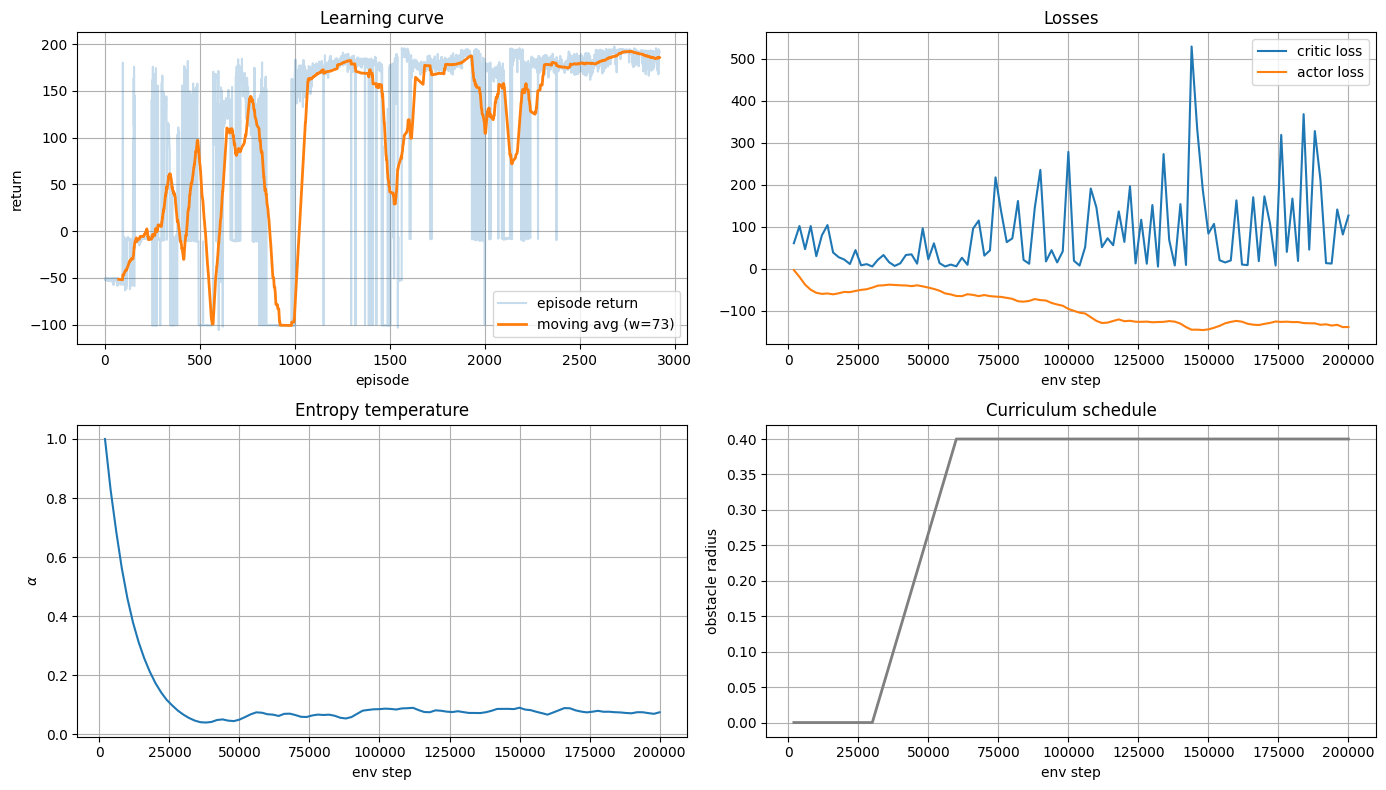

In [ ]:
ret = np.array(history['ep_return']); ep = np.arange(1, len(ret) + 1)
w = max(1, len(ret) // 40)
ma = np.convolve(ret, np.ones(w) / w, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0,0].plot(ep, ret, alpha=0.25, label='episode return')
axes[0,0].plot(np.arange(len(ma)) + w, ma, lw=2, color='C1', label=f'moving avg (w={w})')
axes[0,0].set_xlabel('episode'); axes[0,0].set_ylabel('return')
axes[0,0].set_title('Learning curve'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(history['log_step'], history['loss_q'], label='critic loss')
axes[0,1].plot(history['log_step'], history['loss_pi'], label='actor loss')
axes[0,1].set_xlabel('env step'); axes[0,1].set_title('Losses')
axes[0,1].legend(); axes[0,1].grid(True)

axes[1,0].plot(history['log_step'], history['alpha'])
axes[1,0].set_xlabel('env step'); axes[1,0].set_ylabel(r'$\alpha$')
axes[1,0].set_title('Entropy temperature'); axes[1,0].grid(True)

axes[1,1].plot(history['log_step'], history['obs_r'], lw=2, color='tab:gray')
axes[1,1].set_xlabel('env step'); axes[1,1].set_ylabel('obstacle radius')
axes[1,1].set_title('Curriculum schedule'); axes[1,1].grid(True)
plt.tight_layout(); plt.show()

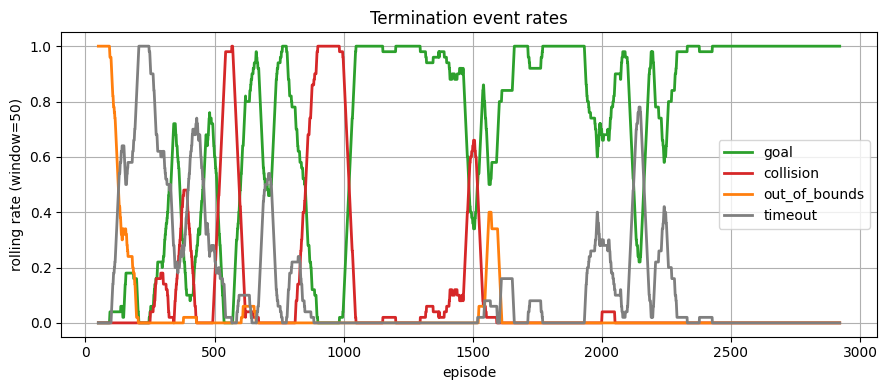

In [ ]:
events = history['event']
def rolling_rate(events, key, w=50):
    arr = np.array([1.0 if e == key else 0.0 for e in events])
    if len(arr) < w: return None, None
    return np.arange(w, len(arr) + 1), np.convolve(arr, np.ones(w) / w, mode='valid')

fig, ax = plt.subplots(figsize=(9, 4))
for key, color in [('goal', 'tab:green'), ('collision', 'tab:red'),('out_of_bounds', 'tab:orange'), ('timeout', 'tab:gray')]:
    x, y = rolling_rate(events, key)
    if x is not None: ax.plot(x, y, label=key, color=color, lw=2)
ax.set_xlabel('episode'); ax.set_ylabel('rolling rate (window=50)')
ax.set_title('Termination event rates'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

## Evaluation: trajectories with the learned policy (full obstacle)

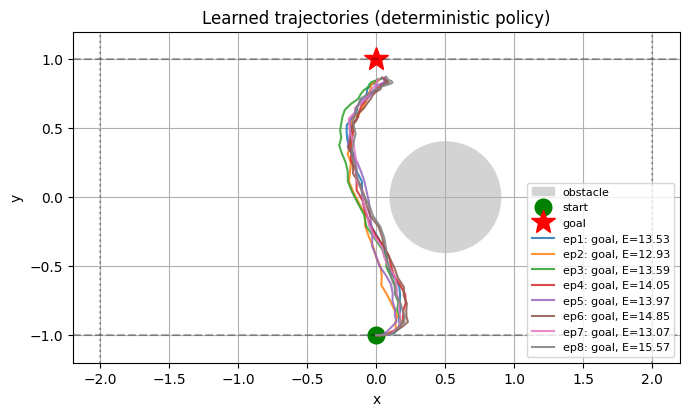

In [ ]:
def rollout(agent, env, deterministic=True):
    s = env.reset(); traj = [[env.x, env.y, env.vx, env.vy]]; acts = []; energy = 0.0
    while True:
        a = agent.act(s, deterministic=deterministic)
        s, r, d, info = env.step(a)
        traj.append([env.x, env.y, env.vx, env.vy]); acts.append(a)
        energy += (a[0]**2 + a[1]**2) * env.dt
        if d: break
    return np.array(traj), np.array(acts), info, energy

N_EVAL = 8
results = []
for k in range(N_EVAL):
    e = UWVEnv(seed=1000 + k, obs_radius=0.4)  # full obstacle for eval
    t, a, info, energy = rollout(agent, e, deterministic=True)
    xf, yf, vxf, vyf = t[-1]
    results.append(dict(traj=t, acts=a, info=info, energy=energy, miss=xf**2 + (yf - 1)**2, speed2=vxf**2 + vyf**2))

fig, ax = plt.subplots(figsize=(7, 7))
theta = np.linspace(0, 2*np.pi, 200)
ax.fill(0.5 + 0.4*np.cos(theta), 0.4*np.sin(theta), color='lightgray', label='obstacle')
ax.plot(0, -1, 'go', ms=12, label='start'); ax.plot(0, 1, 'r*', ms=18, label='goal')
ax.axhline(-1, color='k', ls='--', alpha=0.3); ax.axhline(1, color='k', ls='--', alpha=0.3)
ax.axvline(-2, color='k', ls=':', alpha=0.3); ax.axvline(2, color='k', ls=':', alpha=0.3)
for i, res in enumerate(results):
    t = res['traj']
    ax.plot(t[:, 0], t[:, 1], lw=1.5, alpha=0.85, label=f"ep{i+1}: {res['info']['event']}, E={res['energy']:.2f}")
ax.set_xlim(-2.2, 2.2); ax.set_ylim(-1.2, 1.2); ax.set_aspect('equal')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Learned trajectories (deterministic policy)')
ax.legend(loc='lower right', fontsize=8); ax.grid(True)
plt.tight_layout(); plt.show()

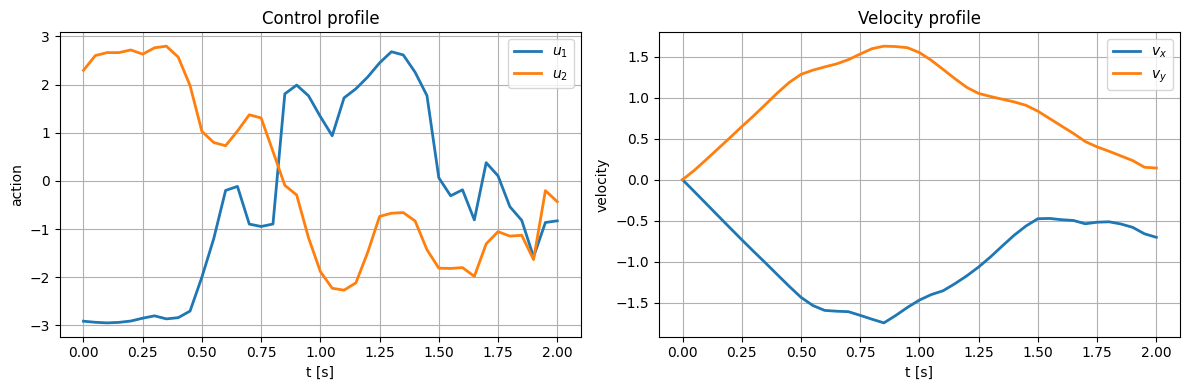

In [ ]:
succ = next((r for r in results if r['info']['event'] == 'goal'), results[0])
acts = succ['acts']; T = len(acts); tt = np.arange(T) * 0.05
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(tt, acts[:, 0], label='$u_1$', lw=2)
ax[0].plot(tt, acts[:, 1], label='$u_2$', lw=2)
ax[0].set_xlabel('t [s]'); ax[0].set_ylabel('action')
ax[0].set_title('Control profile'); ax[0].legend(); ax[0].grid(True)
ax[1].plot(tt, succ['traj'][:-1, 2], label='$v_x$', lw=2)
ax[1].plot(tt, succ['traj'][:-1, 3], label='$v_y$', lw=2)
ax[1].set_xlabel('t [s]'); ax[1].set_ylabel('velocity')
ax[1].set_title('Velocity profile'); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

In [ ]:
M = 50
metrics = []
for k in range(M):
    e = UWVEnv(seed=5000 + k, obs_radius=0.4)
    t, a, info, energy = rollout(agent, e, deterministic=True)
    xf, yf, vxf, vyf = t[-1]
    metrics.append((info['event'], xf**2 + (yf - 1)**2, vxf**2 + vyf**2, energy, len(a) * 0.05))
events = [m[0] for m in metrics]
miss   = np.array([m[1] for m in metrics])
speed2 = np.array([m[2] for m in metrics])
energy = np.array([m[3] for m in metrics])
tf     = np.array([m[4] for m in metrics])
goal_rate = sum(1 for ev in events if ev == 'goal') / M
print(f'Goal reach rate           : {goal_rate*100:.1f}%')
print(f'Miss x^2 + (y-1)^2        : mean {miss.mean():.4f}  median {np.median(miss):.4f}')
print(f'Terminal speed^2          : mean {speed2.mean():.4f}')
print(f'Energy E                  : mean {energy.mean():.3f}')
print(f'Time to finish [s]        : mean {tf.mean():.3f}')
print('Event counts              :', {k: events.count(k) for k in set(events)})

Goal reach rate           : 100.0%
Miss x^2 + (y-1)^2        : mean 0.0207  median 0.0212
Terminal speed^2          : mean 1.0244
Energy E                  : mean 14.488
Time to finish [s]        : mean 2.170
Event counts              : {'goal': 50}
